# QUEST na cvičení
- Dataset pre tento projekt je **Netflix 10+ Year Stock Data** stiahnutý z kaggle.com
- Názov datasetu je NFLX

# IMPORTY

In [1]:
# === IMPORTY ===
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
# Zobrazovanie grafov
%matplotlib inline


df = pd.read_csv("NFLX.csv")
df.head()



,Date,Open,High,Low,Close,Adj Close,Volume
0,2002-05-23,1.156429,1.242857,1.145714,1.196429,1.196429,104790000
1,2002-05-24,1.214286,1.225000,1.197143,1.210000,1.210000,11104800
2,2002-05-28,1.213571,1.232143,1.157143,1.157143,1.157143,6609400
3,2002-05-29,1.164286,1.164286,1.085714,1.103571,1.103571,6757800
4,2002-05-30,1.107857,1.107857,1.071429,1.071429,1.071429,10154200


## 4.1  EDA and data preprocessing

### 4.1(A)	EDA a data preprocessing pre Vami vybrané charakteristiky z datasetu 


Základné informácie o datasete:

In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4581 non-null   datetime64[ns]
 1   Open       4581 non-null   float64       
 2   High       4581 non-null   float64       
 3   Low        4581 non-null   float64       
 4   Close      4581 non-null   float64       
 5   Adj Close  4581 non-null   float64       
 6   Volume     4581 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 250.7 KB


Všetky data su v type int alebo float.

Zistili sme,že dátum je v nesprávnom type preto ho pretypujeme na datetime a zoradíme dataset podľa dátumu

In [9]:
# Pretypovanie dátumu
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Zoradenie podľa dátumu
df = df.sort_values("Date").reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4581 non-null   datetime64[ns]
 1   Open       4581 non-null   float64       
 2   High       4581 non-null   float64       
 3   Low        4581 non-null   float64       
 4   Close      4581 non-null   float64       
 5   Adj Close  4581 non-null   float64       
 6   Volume     4581 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 250.7 KB


Ďalej sme sa pozreli na chýbajúce údaje pomocou nasledujúceho kódu:

In [10]:
print("Počet chýbajúcich hodnôt v jednotlivých stĺpcoch:")
df.isna().sum()

Počet chýbajúcich hodnôt v jednotlivých stĺpcoch:


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Po vípise sme zistili že žiadny stĺpec v datasete nemá chýbajúce údaje, čo je pozitívna informácia

In [11]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,4581,4581.000000,4581.000000,4581.000000,4581.000000,4581.000000,4.581000e+03
mean,2011-06-27 20:17:07.897838592,78.031471,79.285690,76.736079,78.072056,78.072056,1.760516e+07
min,2002-05-23 00:00:00,0.377857,0.410714,0.346429,0.372857,0.372857,2.856000e+05
25%,2006-12-07 00:00:00,3.778571,3.857143,3.685714,3.784286,3.784286,6.908900e+06
50%,2011-06-27 00:00:00,15.392858,15.671429,14.970000,15.324286,15.324286,1.155350e+07
75%,2016-01-14 00:00:00,97.830002,99.529999,96.760002,97.889999,97.889999,2.113440e+07
max,2020-08-03 00:00:00,567.979980,575.369995,520.960022,548.729980,548.729980,3.234140e+08
std,NaN,118.372084,120.276839,116.376768,118.435303,118.435303,1.971130e+07


Časové rozhranie je od roku 2012 až po rok 2020, čo znamená časové rozhranie okolo 18 rokov.

Podľa percentuálneho rozdelenia vidno, že dáta su priemerne rozdelené

Štandardná odchylka je približne 118 čo naznačuje vyokú volatlitu


Dataset neobsahuje záporné hodnoty ani žiadne nelogické hodnoty, čo znamená že dataset je konzistentný

Vývoj cien

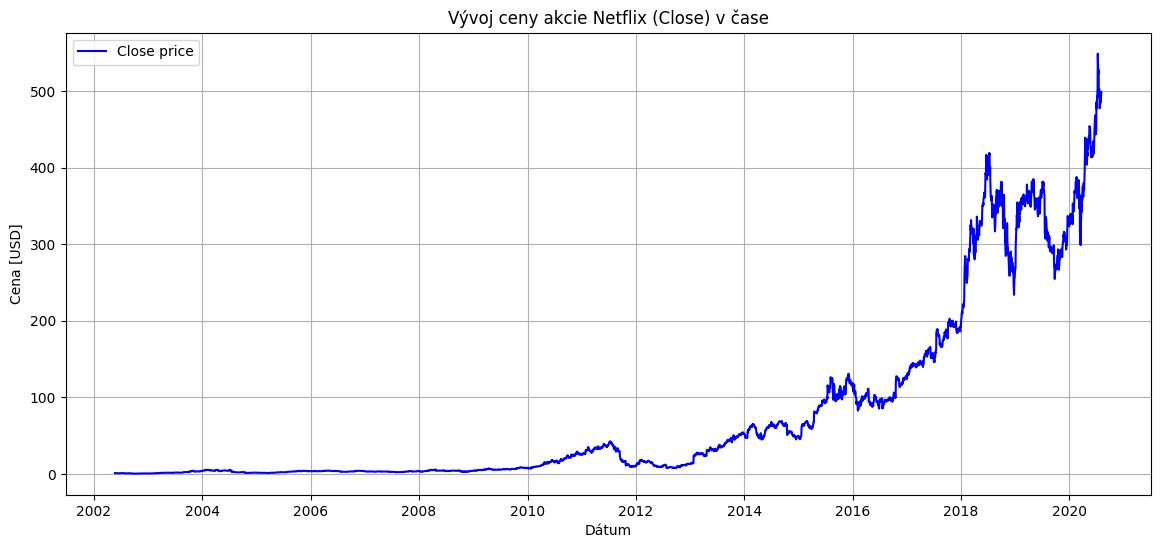

In [12]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Close"], label="Close price", color="blue")
plt.title("Vývoj ceny akcie Netflix (Close) v čase")
plt.xlabel("Dátum")
plt.ylabel("Cena [USD]")
plt.grid(True)
plt.legend()
plt.show()



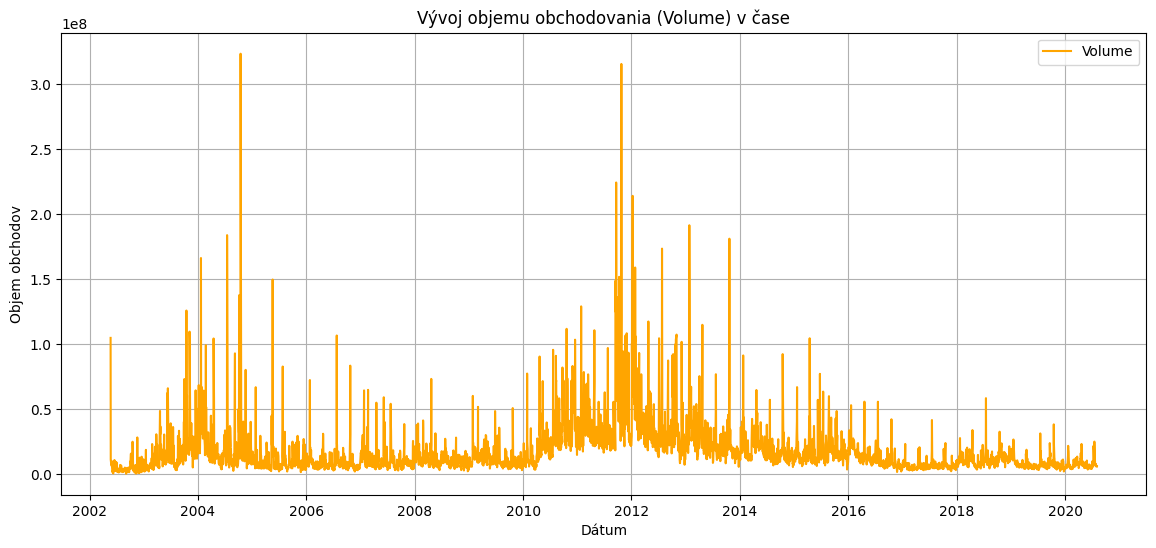

In [13]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Volume"], label="Volume", color="orange")
plt.title("Vývoj objemu obchodovania (Volume) v čase")
plt.xlabel("Dátum")
plt.ylabel("Objem obchodov")
plt.grid(True)
plt.legend()
plt.show()


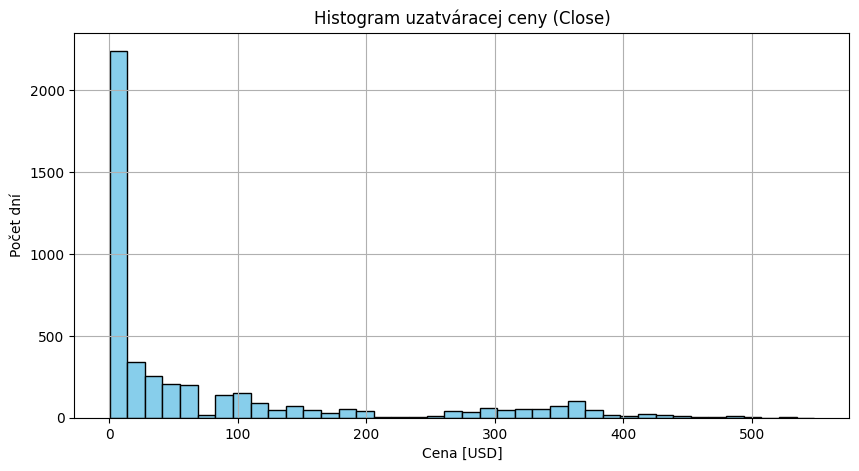

In [14]:
plt.figure(figsize=(10,5))
plt.hist(df["Close"], bins=40, color="skyblue", edgecolor="black")
plt.title("Histogram uzatváracej ceny (Close)")
plt.xlabel("Cena [USD]")
plt.ylabel("Počet dní")
plt.grid(True)
plt.show()


Netflix mal v histórií viacero splitov

To znamená:

- staré ceny boli spätne prepočítané na extrémne nízke hodnoty (1–5 USD)

- nové ceny pred splitmi boli prepočítané smerom nadol

- historické rozdelenie tak nie je prirodzené, ale technicky upravené

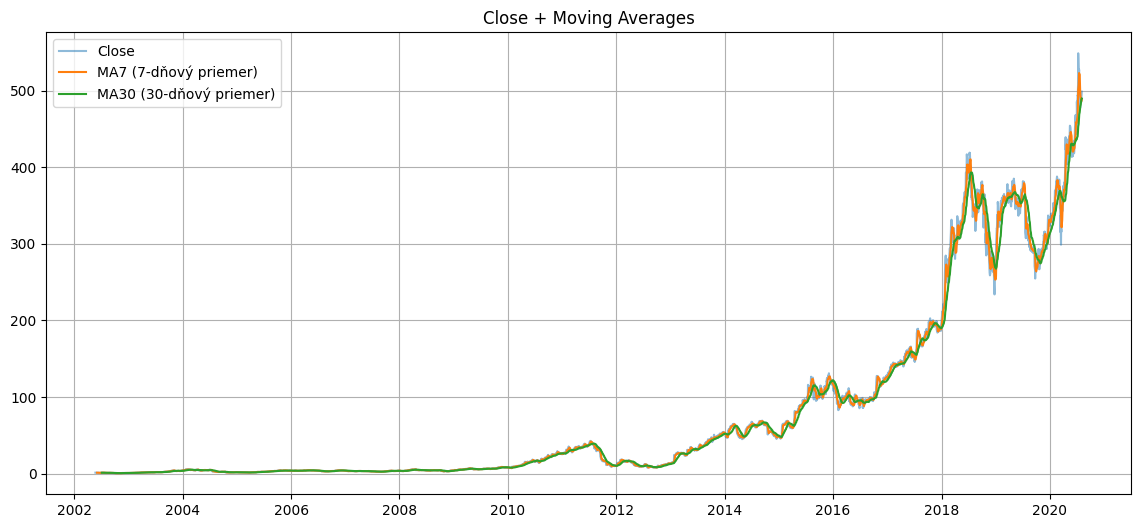

In [15]:
df["MA7"] = df["Close"].rolling(window=7).mean()
df["MA30"] = df["Close"].rolling(window=30).mean()

plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Close"], label="Close", alpha=0.5)
plt.plot(df["Date"], df["MA7"], label="MA7 (7-dňový priemer)")
plt.plot(df["Date"], df["MA30"], label="MA30 (30-dňový priemer)")
plt.title("Close + Moving Averages")
plt.legend()
plt.grid(True)
plt.show()


**MA7** zachytáva krátkodobé výkyvy

**MA30** je hladší a zachytáva trend.

Denné výnosy

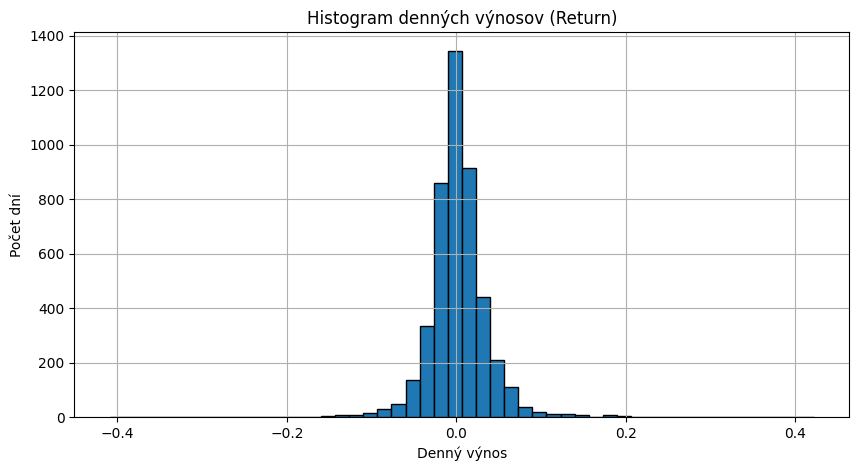

In [16]:

df["Return"] = df["Close"].pct_change()

plt.figure(figsize=(10,5))
plt.hist(df["Return"].dropna(), bins=50, edgecolor="black")
plt.title("Histogram denných výnosov (Return)")
plt.xlabel("Denný výnos")
plt.ylabel("Počet dní")
plt.grid(True)
plt.show()


Väčšina denných výnosov je sústredená blízko 0, čo je typické pre akciové trhy. Rozdelenie má dlhé chvosty – občasné extrémne kladné alebo záporné pohyby predstavujú obdobia vysokej volatility (earnings, správy, krízové udalosti). Tento atribút zachytáva dynamiku zmien ceny lepšie než samotné absolútne hodnoty Close.

Korelačná mapa

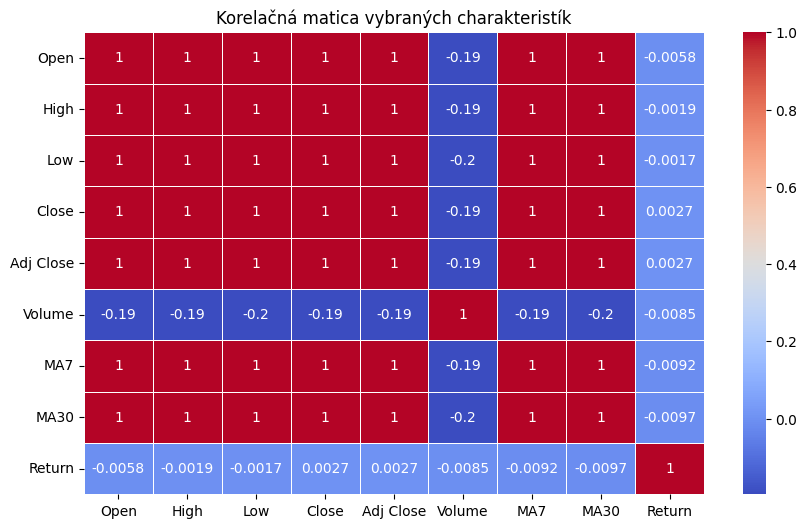

In [17]:
features_for_corr = ["Open", "High", "Low", "Close", "Adj Close", "Volume", "MA7", "MA30", "Return"]
plt.figure(figsize=(10,6))
sns.heatmap(df[features_for_corr].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Korelačná matica vybraných charakteristík")
plt.show()


Medzi cenovými atribútmi (Open, High, Low, Close, Adj Close) vidíme veľmi silnú koreláciu (blízko 1), čo znamená, že nesú podobnú informáciu a sú do veľkej miery redundantné. MA7 a MA30 sú tiež silno korelované s Close, ale zároveň filtrujú krátkodobý šum. Volume má nižšiu koreláciu s cenou, no môže pomôcť zachytiť dni so zvýšenou aktivitou. Return má len slabú koreláciu s úrovňou ceny, čo dáva zmysel – ide o zmenu, nie o samotnú úroveň.

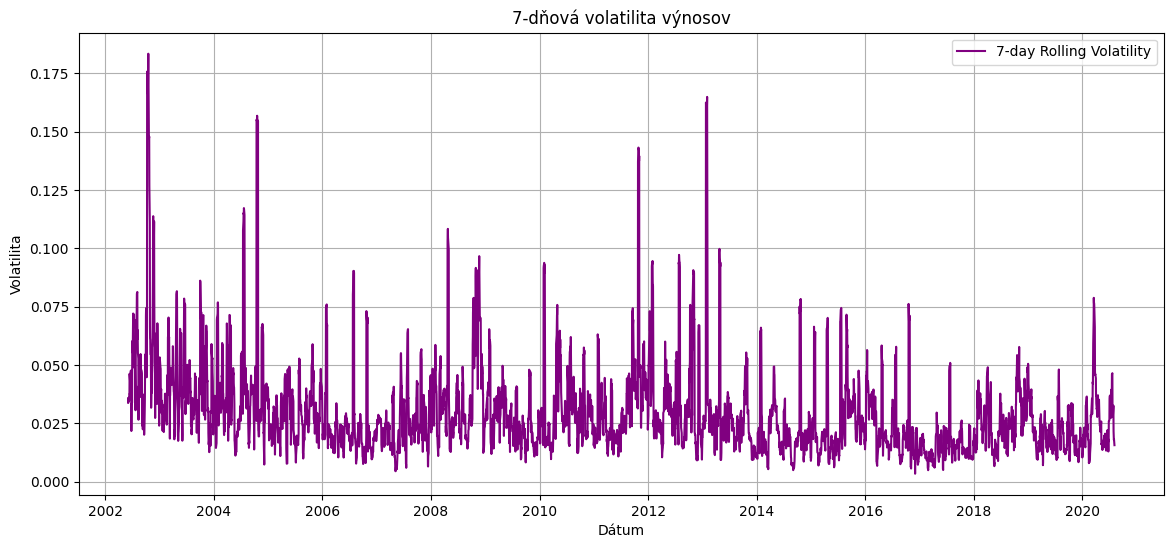

In [ ]:
df["Volatility"] = df["Return"].rolling(window=7).std()

plt.figure(figsize=(14,6))
plt.plot(df["Date"], df["Volatility"], label="7-day Rolling Volatility", color="purple")
plt.title("7-dňová volatilita výnosov")
plt.xlabel("Dátum")
plt.ylabel("Volatilita")
plt.grid(True)
plt.legend()
plt.show()


Volatilita predstavuje mieru kolísania ceny v čase. Vyššie hodnoty volatility znamenajú, že denná zmena ceny bola nestabilná a akcia zaznamenala výraznejšie pohyby. Na grafe vidíme niekoľko výrazných špičiek (napr. okolo rokov 2004, 2008, 2013 a 2015), ktoré typicky súvisia s earnings správami, trhovými šokmi alebo významnými udalosťami v spoločnosti Netflix.

### 4.1(B)	Zdôvodnenie výberu ML/DL metód vzhľadom na vybraný dataset pre 4.2


Kedže v tejto úlohe pracujeme s datasetom Netflix 10+ Year Stock Data, ktorý obsahuje dlhodobý časový rad denných cien akcií, je teda vhodné na základe predošlej analýzy použiť také metódy ktoré dokážu pracovať s časovými radmi alebo zachytiť nelineárne spracovanie dát

**Voľba LM metód**

**Linear regresion**
Lineárna regresia slúži ako základný model. Je rýchla a poskytuje referenčnú hodnotu, voči ktorej môžeme porovnať výkon zložitejších modelov. Napriek tomu, že ceny akcií majú nelineárny vývoj, baseline je dôležitá pre objektívne porovnanie.

**Random Forest Regressor**
Random Forest je vhodný pre finančné dáta, pretože dokáže zachytávať nelineárne vzťahy, je robustný voči outlierom a nevyžaduje normalizáciu.Takisto dobre pracuje s viacerými vstupnými charakteristikami, ktoré môžu byť navzájom korelované (napr. Open, High, Low, Close).

**Gradient Boosting / XGBoost**
Boosting modely patria medzi najúčinnejšie metódy pre tieto dáta. vedia sa naučiť aj zložitejšie vzory, ktoré jednoduchšie modely nemusia vidieť. Veľmi dobre pracujú s trendom aj s volatilitou. Výhodou sú dobré vysledky aj pri menšich datasetoch čo sa nám akurát hodi


## 4.2 Modeling evaluation

### 4.2(A)	Modeluje Vami tie vybrané charakteristiky pomocou vhodných ML/DL metód. Výsledok modelovania je najlepší model.

### 4.2(B)	Zhodnotíte Váš prístup a získaný výsledok